In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import roc_auc_score
from collections import defaultdict

In [ ]:
import kagglehub
path = kagglehub.dataset_download("nibinv23/iam-handwriting-word-database")
print(path)

100%|██████████| 1.10G/1.10G [00:12<00:00, 95.8MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/nibinv23/iam-handwriting-word-database/versions/2


In [ ]:
from glob import glob
from multiprocessing import Pool, cpu_count
import os

IMG_H, IMG_W = 200, 100
WORDS_DIR = os.path.join(path, "iam_words", "words")

def process_file(path):
    file = os.path.basename(path)
    writer_id = file.split("-")[1]
    return (path, writer_id)

def load_parallel(words_dir):
    files = glob(words_dir + "/**/*.png", recursive=True)

    with Pool(cpu_count()) as p:
        data = p.map(process_file, files)

    return data

data = load_parallel(WORDS_DIR)
print("Total images:", len(data))

Total images: 115320


In [ ]:
def group_by_writer(data):
    writer_dict = defaultdict(list)
    for img, w in data:
        writer_dict[w].append(img)
    return writer_dict

writer_dict = group_by_writer(data)
print("Total writers:", len(writer_dict))

Total writers: 505


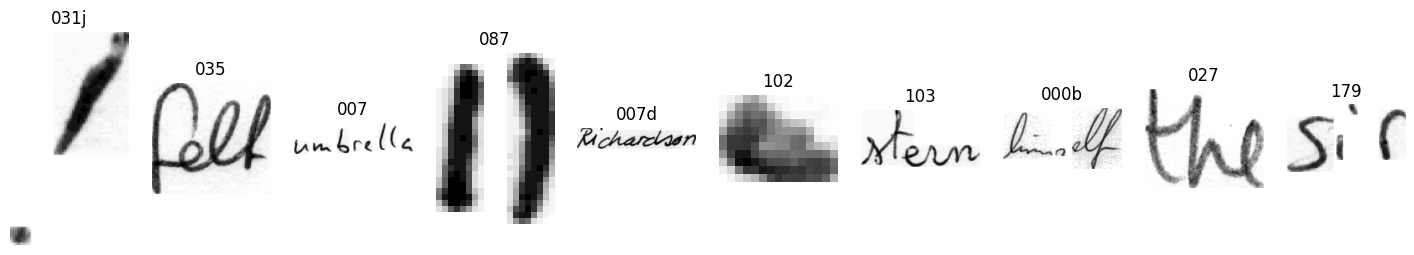

In [ ]:
def show_sample_images(data, num_samples=10):
    samples = random.sample(data, num_samples)

    plt.figure(figsize=(18, 3))
    for i, (img_path, writer) in enumerate(samples):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(writer)
        plt.axis("off")

    plt.show()

show_sample_images(data)

In [ ]:
def estimate_pair_counts(writer_dict):
    total_samples = sum(len(v) for v in writer_dict.values())
    total_writers = len(writer_dict)

    total_positive = 0
    writer_stats = []

    for w, imgs in writer_dict.items():
        n = len(imgs)

        if n >= 2:
            pos = (n * (n - 1)) // 2
            total_positive += pos
            writer_stats.append((w, n, pos))

    # Approx negative estimation
    # total pairs - positive pairs
    total_possible_pairs = (total_samples * (total_samples - 1)) // 2
    total_negative = total_possible_pairs - total_positive

    print("Total writers:", total_writers)
    print("Total samples:", total_samples)
    print("Total positive pairs (exact):", total_positive)
    print("Total negative pairs (approx):", total_negative)
    print("Total possible pairs:", total_possible_pairs)

estimate_pair_counts(writer_dict)

Total writers: 505
Total samples: 115320
Total positive pairs (exact): 31523919
Total negative pairs (approx): 6617769621
Total possible pairs: 6649293540


In [ ]:
# Data Preprocessing
def preprocess_img(path, mode="gray", target_size=(200,100)):
    if mode == "gray":
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None

        img = cv2.resize(img, target_size)
        img = img.astype("float32") / 255.0
        return np.expand_dims(img, -1)

    elif mode == "rgb":
        img = cv2.imread(path)
        if img is None:
            return None

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, target_size)

        img = img.astype("float32")
        return img

def prepare_data(pairs):
    X1, X2, Y = [], [], []

    skipped = 0

    for img1, img2, label in pairs:
        p1 = preprocess_img(img1)
        p2 = preprocess_img(img2)

        if p1 is None or p2 is None:
            skipped += 1
            continue

        X1.append(p1)
        X2.append(p2)
        Y.append(label)

    print(f"⚠️ Skipped bad pairs: {skipped}")

    return np.array(X1), np.array(X2), np.array(Y)

In [ ]:
def generate_balanced_pairs(writer_dict, pos_target, neg_target):
    writers = list(writer_dict.keys())

    # ---------- POSITIVE (sampled) ----------
    positive_pairs = []

    while len(positive_pairs) < pos_target:
        w = random.choice(writers)
        imgs = writer_dict[w]

        if len(imgs) < 2:
            continue

        img1, img2 = random.sample(imgs, 2)
        positive_pairs.append((img1, img2, 1))

    # ---------- NEGATIVE (already correct) ----------
    negative_pairs = []

    while len(negative_pairs) < neg_target:
        w1, w2 = random.sample(writers, 2)

        img1 = random.choice(writer_dict[w1])
        img2 = random.choice(writer_dict[w2])

        negative_pairs.append((img1, img2, 0))

    positive_pairs = list(set(positive_pairs))
    negative_pairs = list(set(negative_pairs))

    return positive_pairs + negative_pairs

def pair_generator(pairs, batch_size=32, mode="gray", target_size=(200,100)):
    while True:
        random.shuffle(pairs)

        for i in range(0, len(pairs), batch_size):
            batch = pairs[i:i+batch_size]

            X1, X2, Y = [], [], []

            for img1, img2, label in batch:
                p1 = preprocess_img(img1, mode, target_size)
                p2 = preprocess_img(img2, mode, target_size)

                if p1 is None or p2 is None:
                    continue

                X1.append(p1)
                X2.append(p2)
                Y.append(label)

            if len(X1) == 0:
                continue

            yield (np.array(X1), np.array(X2)), np.array(Y)

In [ ]:
def leave_k_out_split(writer_dict, k):
    writers = list(writer_dict.keys())
    random.shuffle(writers)

    test_writers = writers[:k]
    train_writers = writers[k:]

    train_dict = {w: writer_dict[w] for w in train_writers}
    test_dict = {w: writer_dict[w] for w in test_writers}

    return train_dict, test_dict


def run_leave_k_out_balanced(data, k=15, runs=1):  # keep 1 for now
    writer_dict = group_by_writer(data)

    train_dict, test_dict = leave_k_out_split(writer_dict, k)

    train_pairs = generate_balanced_pairs(train_dict, 18000, 18000)
    test_pairs  = generate_balanced_pairs(test_dict, 4500, 4500)

    random.shuffle(train_pairs)
    random.shuffle(test_pairs)

    print("Train pairs:", len(train_pairs))
    print("Test pairs:", len(test_pairs))

    return train_pairs, test_pairs

In [ ]:
def show_pairs(pairs, num=5):
    pos_pairs = [p for p in pairs if p[2] == 1]
    neg_pairs = [p for p in pairs if p[2] == 0]

    pos_samples = random.sample(pos_pairs, min(num, len(pos_pairs)))
    neg_samples = random.sample(neg_pairs, min(num, len(neg_pairs)))

    # -------- POSITIVE PAIRS --------
    plt.figure(figsize=(12, 4))
    for i, (img1, img2, _) in enumerate(pos_samples):
        im1 = cv2.imread(img1, cv2.IMREAD_GRAYSCALE)
        im2 = cv2.imread(img2, cv2.IMREAD_GRAYSCALE)

        plt.subplot(2, num, i+1)
        plt.imshow(im1, cmap='gray')
        plt.title("Same Writer")
        plt.axis('off')

        plt.subplot(2, num, i+1+num)
        plt.imshow(im2, cmap='gray')
        plt.axis('off')

    plt.suptitle("Positive Pairs (Same Writer)")
    plt.show()

    # -------- NEGATIVE PAIRS --------
    plt.figure(figsize=(12, 4))
    for i, (img1, img2, _) in enumerate(neg_samples):
        im1 = cv2.imread(img1, cv2.IMREAD_GRAYSCALE)
        im2 = cv2.imread(img2, cv2.IMREAD_GRAYSCALE)

        plt.subplot(2, num, i+1)
        plt.imshow(im1, cmap='gray')
        plt.title("Different Writers")
        plt.axis('off')

        plt.subplot(2, num, i+1+num)
        plt.imshow(im2, cmap='gray')
        plt.axis('off')

    plt.suptitle("Negative Pairs (Different Writers)")
    plt.show()

Train pairs: 35965
Test pairs: 8894


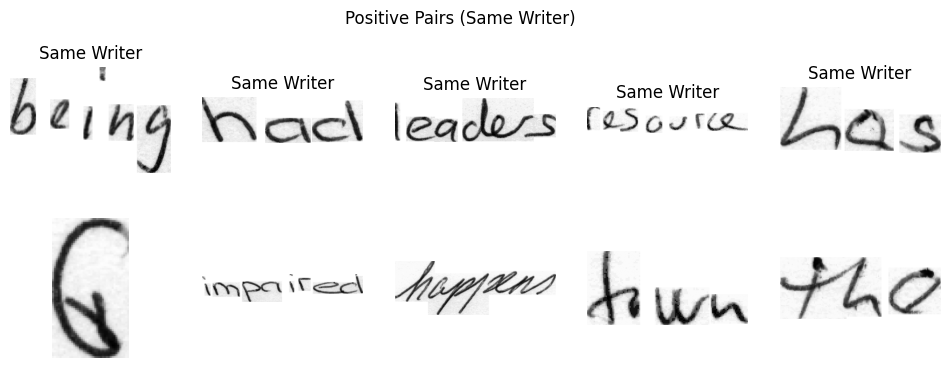

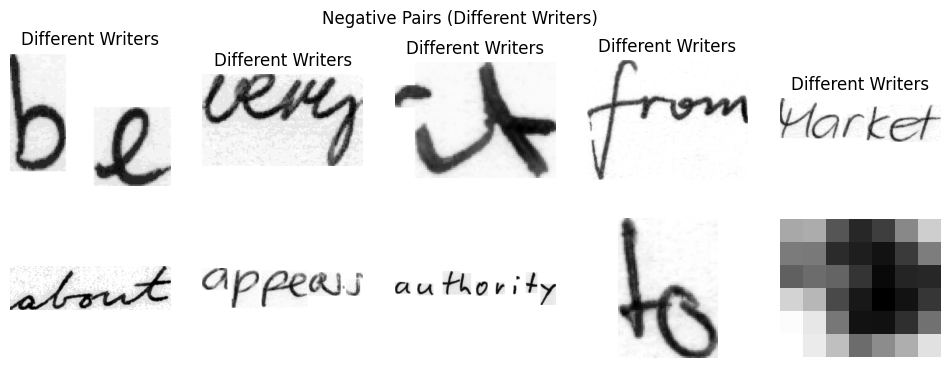

In [ ]:
train_pairs, test_pairs = run_leave_k_out_balanced(data)

show_pairs(train_pairs, num=5)

train_gen_gray = pair_generator(train_pairs, mode="gray", target_size=(200,100))
test_gen_gray  = pair_generator(test_pairs, mode="gray", target_size=(200,100))

train_gen_rgb = pair_generator(train_pairs, mode="rgb", target_size=(224,224))
test_gen_rgb  = pair_generator(test_pairs, mode="rgb", target_size=(224,224))

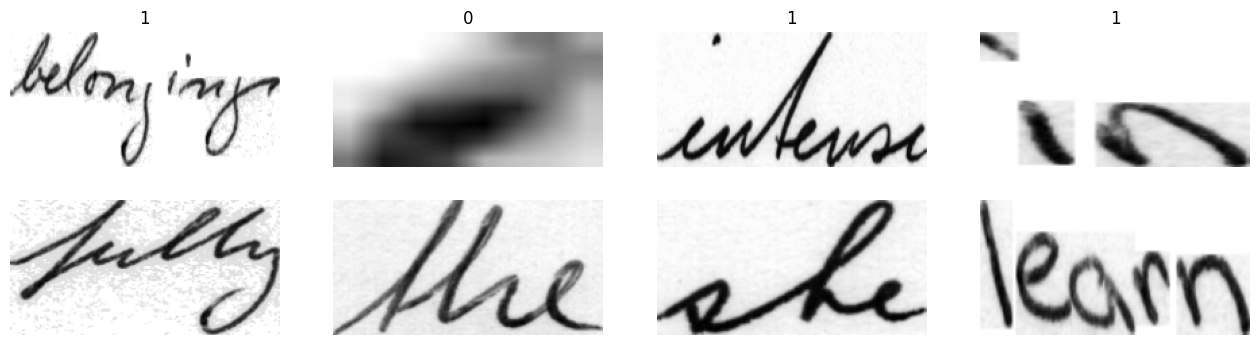

In [ ]:
def show_sample_from_generator(gen):
    (X1, X2), Y = next(gen)

    plt.figure(figsize=(16,4))
    for i in range(4):
        plt.subplot(2,4,i+1)
        plt.imshow(X1[i].squeeze(), cmap="gray")
        plt.title(Y[i])
        plt.axis("off")

        plt.subplot(2,4,i+5)
        plt.imshow(X2[i].squeeze(), cmap="gray")
        plt.axis("off")

    plt.show()

show_sample_from_generator(pair_generator(train_pairs, mode="gray"))

In [ ]:
def build_siamese_baseCNN(input_shape=(100,200,1), embed_dim=256, lr=1e-4):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(embed_dim, activation='relu')(x)
    x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)

    embedder = models.Model(inp, x)

    # Siamese
    a = layers.Input(shape=input_shape)
    b = layers.Input(shape=input_shape)

    ea = embedder(a)
    eb = embedder(b)

    diff = layers.Lambda(lambda t: tf.abs(t[0] - t[1]))([ea, eb])
    out = layers.Dense(1, activation='sigmoid')(diff)

    model = models.Model([a, b], out)
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model, embedder

In [ ]:
def build_siamese_efficientnet(input_shape=(224,224,3), embed_dim=256, lr=1e-4):

    # 🔹 Load pretrained EfficientNet
    base = tf.keras.applications.EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    base.trainable = False   # freeze initially

    # 🔹 Embedding network
    inp = layers.Input(shape=input_shape)

    x = tf.keras.applications.efficientnet.preprocess_input(inp)
    x = base(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(embed_dim, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)

    embedder = models.Model(inp, x, name="efficientnet_embedder")

    # 🔹 Siamese structure
    a = layers.Input(shape=input_shape)
    b = layers.Input(shape=input_shape)

    ea = embedder(a)
    eb = embedder(b)

    diff = layers.Lambda(lambda t: tf.abs(t[0] - t[1]))([ea, eb])
    out = layers.Dense(1, activation='sigmoid')(diff)

    model = models.Model([a, b], out, name="siamese_efficientnet")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model, embedder

In [ ]:
def attention_block(x):
    attn = layers.Conv2D(1, (1,1), activation='sigmoid')(x)
    return layers.Multiply()([x, attn])


def build_siamese_attention(input_shape=(100,200,1), embed_dim=256, lr=1e-4):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = attention_block(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = attention_block(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(embed_dim, activation='relu')(x)
    x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)

    embedder = models.Model(inp, x)

    # Siamese head same as before
    a = layers.Input(shape=input_shape)
    b = layers.Input(shape=input_shape)

    ea = embedder(a)
    eb = embedder(b)

    diff = layers.Lambda(lambda t: tf.abs(t[0] - t[1]))([ea, eb])
    out = layers.Dense(1, activation='sigmoid')(diff)

    model = models.Model([a, b], out)
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model, embedder

In [ ]:
def build_siamese_vit(input_shape=(224,224,3), embed_dim=256, lr=1e-4):
    inp = layers.Input(shape=input_shape)

    # Patch embedding
    x = layers.Conv2D(64, kernel_size=16, strides=16)(inp)
    x = layers.Reshape((-1, 64))(x)

    x = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = layers.LayerNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(embed_dim, activation='relu')(x)
    x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)

    embedder = models.Model(inp, x)

    a = layers.Input(shape=input_shape)
    b = layers.Input(shape=input_shape)

    ea = embedder(a)
    eb = embedder(b)

    diff = layers.Lambda(lambda t: tf.abs(t[0] - t[1]))([ea, eb])
    out = layers.Dense(1, activation='sigmoid')(diff)

    model = models.Model([a, b], out)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model, embedder

In [ ]:
def train_and_evaluate(model, train_gen, test_gen, train_pairs, test_pairs, name):
    print(f"\n Training {name}")

    steps = len(train_pairs)//64
    val_steps = len(test_pairs)//64

    history = model.fit(
        train_gen,
        steps_per_epoch=steps,
        validation_data=test_gen,
        validation_steps=val_steps,
        epochs=20,
        verbose=1
    )

    # 🔥 LOSS CURVE (Cross-Entropy)
    plt.figure(figsize=(6, 4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f"{name} Loss Curve")
    plt.xlabel('Epochs')
    plt.ylabel('Binary Cross-Entropy Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Evaluate
    y_true = []
    y_pred = []

    for _ in range(val_steps):
        (X1, X2), y = next(test_gen)
        preds = model.predict([X1, X2], verbose=0)

        y_true.extend(y)
        y_pred.extend(preds.flatten())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    auc = roc_auc_score(y_true, y_pred)

    print(f"{name} AUC:", auc)

    return {
        "name": name,
        "accuracy": history.history['val_accuracy'][-1],
        "loss": history.history['val_loss'][-1],
        "auc": auc,
        "history": history.history   # optional (useful later)
    }


 Training Base CNN
Epoch 1/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 34s 52ms/step - accuracy: 0.5424 - loss: 0.6756 - val_accuracy: 0.6243 - val_loss: 0.6533
Epoch 2/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.6263 - loss: 0.6569 - val_accuracy: 0.6846 - val_loss: 0.6280
Epoch 3/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 32s 57ms/step - accuracy: 0.6606 - loss: 0.6460 - val_accuracy: 0.7077 - val_loss: 0.6166
Epoch 4/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - accuracy: 0.6639 - loss: 0.6424 - val_accuracy: 0.7024 - val_loss: 0.6211
Epoch 5/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 30s 53ms/step - accuracy: 0.6725 - loss: 0.6383 - val_accuracy: 0.7093 - val_loss: 0.6060
Epoch 6/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.6775 - loss: 0.6312 - val_accuracy: 0.7251 - val_loss: 0.6005
Epoch 7/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 32s 56ms/step - accuracy: 0.6887 - loss: 0.6282 - val_accuracy: 0.7168 - val_loss: 0.6027
Epoch 8/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 36s 64ms/step - accuracy: 0.69

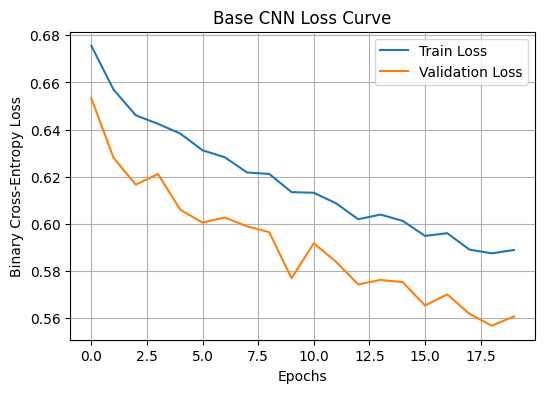

Base CNN AUC: 0.8035424803644928


In [ ]:


# 1. Base CNN
model, _ = build_siamese_baseCNN()
results.append(train_and_evaluate(model, train_gen_gray, test_gen_gray,
                                  train_pairs, test_pairs, "Base CNN"))

#
# model, _ = build_siamese_efficientnet()
# results.append(train_and_evaluate(model, train_gen_rgb, test_gen_rgb,
#                                   train_pairs, test_pairs, "EfficientNetB0"))

# # 3. Attention CNN
# model, _ = build_siamese_attention()
# results.append(train_and_evaluate(model, train_gen_gray, test_gen_gray,
#                                   train_pairs, test_pairs, "Attention CNN"))

# # 4. ViT
# model, _ = build_siamese_vit()
# results.append(train_and_evaluate(model, train_gen_rgb, test_gen_rgb,
#                                   train_pairs, test_pairs, "ViT"))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 Training EfficientNetB0
Epoch 1/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 106s 108ms/step - accuracy: 0.5148 - loss: 0.6929 - val_accuracy: 0.5197 - val_loss: 0.6893
Epoch 2/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 89s 159ms/step - accuracy: 0.5254 - loss: 0.6905 - val_accuracy: 0.5797 - val_loss: 0.6835
Epoch 3/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 49s 88ms/step - accuracy: 0.5560 - loss: 0.6862 - val_accuracy: 0.5806 - val_loss: 0.6804
Epoch 4/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 49s 88ms/step - accuracy: 0.5682 - loss: 0.6828 - val_accuracy: 0.5879 - val_loss: 0.6746
Epoch 5/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 82s 147ms/step - accuracy: 0.5819 - loss: 0.6790 - val_accuracy: 0.6311 - val_loss: 0.6685
Epoch 6/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 82s 145ms/step - accuracy: 0.5918 - loss: 0.6769 - val_accuracy: 0.6414 - val_loss: 0.6642
Epoch 7/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 49s 88ms/step - accuracy: 0.6067 - loss: 0.6725 - val_accuracy: 0.6368 - val_loss: 0.6618
Epoch 8/

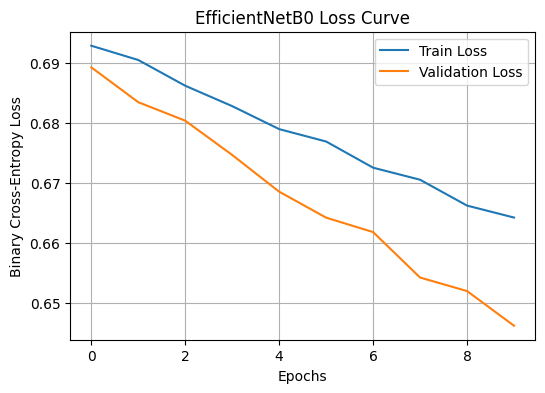

EfficientNetB0 AUC: 0.7228772687292818


In [ ]:
# 2. EfficientNetB0
model, _ = build_siamese_efficientnet()
results.append(train_and_evaluate(model, train_gen_rgb, test_gen_rgb,
                                  train_pairs, test_pairs, "EfficientNetB0"))

In [ ]:
# 3. Attention CNN
model, _ = build_siamese_attention()
results.append(train_and_evaluate(model, train_gen_gray, test_gen_gray,
                                  train_pairs, test_pairs, "Attention CNN"))



 Training ViT
Epoch 1/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 50s 78ms/step - accuracy: 0.5387 - loss: 0.6844 - val_accuracy: 0.6253 - val_loss: 0.6601
Epoch 2/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 81s 145ms/step - accuracy: 0.6024 - loss: 0.6700 - val_accuracy: 0.6329 - val_loss: 0.6545
Epoch 3/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 43s 76ms/step - accuracy: 0.6042 - loss: 0.6695 - val_accuracy: 0.5804 - val_loss: 0.6832
Epoch 4/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 42s 75ms/step - accuracy: 0.5782 - loss: 0.6770 - val_accuracy: 0.6370 - val_loss: 0.6505
Epoch 5/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 42s 74ms/step - accuracy: 0.6104 - loss: 0.6651 - val_accuracy: 0.6559 - val_loss: 0.6375
Epoch 6/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.6198 - loss: 0.6599 - val_accuracy: 0.6653 - val_loss: 0.6328
Epoch 7/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.6188 - loss: 0.6592 - val_accuracy: 0.6599 - val_loss: 0.6335
Epoch 8/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 40s 71ms/step - accuracy: 0.6114 -

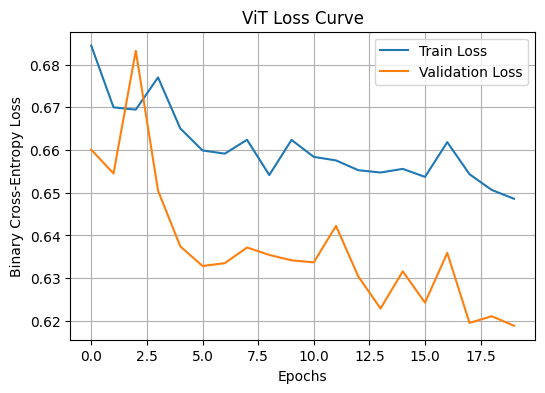

ViT AUC: 0.6953617536434122


In [ ]:
 # 4. ViT
results = []
model, _ = build_siamese_vit()
results.append(train_and_evaluate(model, train_gen_rgb, test_gen_rgb,
                                  train_pairs, test_pairs, "ViT"))

In [ ]:
import pandas as pd

df = pd.DataFrame(results)
print(df)

  name  accuracy      loss       auc  \
0  ViT  0.641984  0.636455  0.701721   

                                             history  
0  {'accuracy': [0.5257353186607361, 0.5822749733...  


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(df["name"], df["accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(10,5))

plt.bar(df["name"], df["auc"])
plt.title("ROC-AUC Comparison")
plt.ylabel("AUC")
plt.show()